# 04 — Random Forest
Walk-forward Random Forest on weekly silver log-returns with lagged features.
Same train/val/test split and evaluation metrics as the ARIMA, LSTM, and XGBoost notebooks.

### Roadmap

| § | Step | What happens |
|---|---|---|
| 1 | Load features | Read the shared weekly W-FRI frame (`features_weekly.csv`) + `feature_groups.json`; pull the silver target and `split`. |
| 2 | Build feature groups | Build the EXOG base (silver lags + 6 cross-asset returns) and every ablation group up front, incl. the `EXOG+ALL` kitchen sink. |
| 3 | Tuning + walk-forward helpers | `tune()` grid-searches per variant via `TimeSeriesSplit(5)` on train+val; `walk_forward()` retrains every 4 weeks (expanding + rolling-100w). |
| 4 | Variant ladder | The single ladder — EXOG is rung 0, then GS / NonLin / Tech / Macro / FRED / COT / Sentiment groups + `EXOG+ALL`; each run in both windows. |
| 5 | Evaluate | One table — RMSE / MAE / OOS R² / DA / WDA for Naive, Drift, every variant. Save `metrics_rf.csv`. |
| 6 | Sub-period robustness | Pick the best variant by RMSE (primary) and WDA (secondary); break down by `PERIODS`; save period + preds CSVs. |
| 7 | Predicted vs actual | Full window, two panels (WDA-best, RMSE-best), drift overlaid. |
| 8 | Significance tests | Load-bearing DM vs-Drift floor (OOS R² + DM, squared & absolute error). 8b: Pesaran–Timmermann directional lens. 8c: ex-2025 robustness. |
| 9 | 2026 zoom | WDA-best and RMSE-best vs the drift floor on the 2026 YTD slice. |
| 10 | Feature importance | Permutation importance (OOS test window) from a single RF fit on the `EXOG+ALL` model — descriptive, not a load-bearing test. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from itertools import product
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load features

In [2]:
# Weekly feature frame (built once by 02_features.ipynb §8 — single source of truth).
weekly = pd.read_csv('../../../data/processed/features_weekly.csv', index_col=0, parse_dates=True)

TARGET       = 'silver_return'
EXOG_RETURNS = ['gold_return', 'usd_return', 'copper_return', 'sp500_return',
                'vix_return', 'oil_return']
EXOG_LEVELS  = ['gs_ratio_z']   # level feature — separate group for ablation (see §8)
EXOG         = EXOG_RETURNS + EXOG_LEVELS

# Base weekly matrix: target + cross-asset returns + gs_ratio_z. The frame is un-lagged
# (build_features applies the 1-week lag); the W-FRI aggregation lives in 02_features.
base_cols = [TARGET] + EXOG_RETURNS + EXOG_LEVELS
all_w   = weekly[base_cols].dropna().copy()
n_train = int((weekly.loc[all_w.index, 'split'] != 'test').sum())

print(f'Weekly obs — train+val: {n_train}, test: {len(all_w) - n_train}')
print(f'Features available: {[c for c in EXOG if c in all_w.columns]}')

Weekly obs — train+val: 417, test: 174
Features available: ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return', 'gs_ratio_z']


## 2. Build all feature groups

Build every feature set up front — the EXOG base (silver AR lags + 6 cross-asset return lags) and
all ablation groups (GS / NonLin / Tech / Macro / FRED_daily / COT / sentiment / BestLag) — so the
variant ladder (§4) is the *only* place models are fit. Base groups get the 1-week lag here; TECH /
MACRO are already lagged in the frame; BestLag columns are pre-lagged (used as-is). A missing column
errors loudly (the frame always carries every group).

In [3]:
import json
GROUPS = json.load(open('../../../data/processed/feature_groups.json'))

def build_features(df):
    '''EXOG base: 6 lagged cross-asset returns + silver AR lags 1-3 (gs_ratio_z is its own +GS rung).'''
    X = pd.DataFrame(index=df.index)
    for col in [c for c in EXOG_RETURNS if c in df.columns]:
        X[f'{col}_lag1'] = df[col].shift(1)
    for lag in [1, 2, 3]:
        X[f'silver_lag{lag}'] = df[TARGET].shift(lag)
    return X

features_all = build_features(all_w)

# Test target / index (used by the ladder + everything downstream).
y_test     = all_w[TARGET].iloc[n_train:].values
test_index = all_w.index[n_train:]

# -- Ablation groups, each as {feature_name: weekly_series} -----------------------
def lag1(cols):
    return {f'{c}_lag1': weekly[c].shift(1) for c in cols}

GS_COLS       = lag1(GROUPS['GS'])
FRED_COLS     = lag1(GROUPS['FRED_DAILY'])
COT_COLS      = lag1(GROUPS['COT'])
SENT_COLS     = lag1(GROUPS['SENT'])
REDDIT_COLS   = {'reddit_sentiment_lag1': SENT_COLS['reddit_sentiment_lag1']}
NEWS_COLS     = {'news_sentiment_lag1':   SENT_COLS['news_sentiment_lag1']}
NEWSPAID_COLS = {'news_paid_sentiment_title_lag1': weekly['news_paid_sentiment_title'].shift(1)}  # paid-news, title only
SENTPAID_COLS = {**REDDIT_COLS, **NEWSPAID_COLS}         # reddit + paid-news title (paid twin of SENT_COLS)
PMI_COLS      = lag1(GROUPS['PMI'])                      # china_pmi_proxy -- point-in-time level, lagged 1w
MACRO_COLS    = {c: weekly[c] for c in GROUPS['MACRO']}   # leak-corrected, already lagged
MACROCOT_COLS = {**FRED_COLS, **COT_COLS}
tech_dict     = lag1(GROUPS['TECH'])                      # directional -- lagged 1w here, like GS/FRED/COT
BESTLAG_ALL_COLS   = {c: weekly[c] for c in GROUPS['BESTLAG_ALL']}    # pre-lagged (used as-is)
BESTLAG_SIG90_COLS = {c: weekly[c] for c in GROUPS['BESTLAG_SIG90']}
BESTLAG_SIG_COLS   = {c: weekly[c] for c in GROUPS['BESTLAG_SIG']}

SILVER_LAGS = [c for c in features_all.columns if c.startswith('silver_lag')]
ALL_BASE    = list(features_all.columns)                  # silver lags + cross-asset return lags
NONLIN_COLS = {f'{c}_sq': features_all[c] ** 2 for c in features_all.columns}   # squared lags
# Kitchen-sink extras (the EXOG+ALL rung + the feature-importance model).
ALL_EXTRA   = {**GS_COLS, **NONLIN_COLS, **tech_dict, **MACROCOT_COLS, **SENT_COLS}
ALL_EXTRA_PAID = {**GS_COLS, **NONLIN_COLS, **tech_dict, **MACROCOT_COLS, **SENTPAID_COLS}   # EXOG+ALL, paid-news title in the sentiment slot

print(f'EXOG base ({len(ALL_BASE)}):', ALL_BASE)
print(f'EXOG+ALL feature count: {len(ALL_BASE) + len(ALL_EXTRA)}')

EXOG base (9): ['gold_return_lag1', 'usd_return_lag1', 'copper_return_lag1', 'sp500_return_lag1', 'vix_return_lag1', 'oil_return_lag1', 'silver_lag1', 'silver_lag2', 'silver_lag3']
EXOG+ALL feature count: 36


## 3. Tuning + walk-forward helpers

`tune()` grid-searches the RF hyperparameters via `TimeSeriesSplit(5)` CV on **train+val** (no test
peek). `walk_forward()` does 1-step-ahead forecasting, refitting every 4 weeks, expanding (default)
or rolling-100w. Each variant is tuned on its **own** feature set in the ladder (§4) — so a
difference between rungs is the features given each its best hyperparameters, not a shared HP handicap.

In [4]:
param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [6, 8, None],   # None = fully grown trees (RF default)
    'min_samples_leaf': [3, 5, 10],
    'max_features':     ['sqrt', 0.7],
}
tscv   = TimeSeriesSplit(n_splits=5)
keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f'Grid: {len(combos)} combinations per variant')

def tune(X_tr_s, y_tr_s):
    '''Grid-search RF hyperparameters by TimeSeriesSplit CV-RMSE on train+val.'''
    mask_s = ~np.isnan(X_tr_s).any(axis=1)
    X_tr_s, y_tr_s = X_tr_s[mask_s], y_tr_s[mask_s]
    best_rmse_s, best_params_s = np.inf, {}
    for combo in combos:
        params = dict(zip(keys, combo))
        fold_rmses = []
        for fold_tr, fold_val in tscv.split(X_tr_s):
            m = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
            m.fit(X_tr_s[fold_tr], y_tr_s[fold_tr])
            fold_rmses.append(np.sqrt(mean_squared_error(y_tr_s[fold_val], m.predict(X_tr_s[fold_val]))))
        rmse = np.mean(fold_rmses)
        if rmse < best_rmse_s:
            best_rmse_s, best_params_s = rmse, params
    return best_params_s

def walk_forward(all_w, features_all, n_train, feature_cols,
                 retrain_every=4, window=None, **rf_kwargs):
    '''window=None -> expanding; window=N -> rolling (last N weeks). Refit every retrain_every.'''
    y_all = all_w[TARGET].values
    X_all = features_all[feature_cols].values
    preds = np.full(len(all_w) - n_train, np.nan)
    model = None
    for i, t in enumerate(range(n_train, len(all_w))):
        start = max(0, t - window) if window else 0
        X_tr, y_tr = X_all[start:t], y_all[start:t]
        X_te = X_all[t:t+1]
        mask = ~np.isnan(X_tr).any(axis=1)
        if mask.sum() < 10 or np.isnan(X_te).any():
            continue
        if model is None or i % retrain_every == 0:
            model = RandomForestRegressor(random_state=42, n_jobs=-1, **rf_kwargs)
            model.fit(X_tr[mask], y_tr[mask])
        preds[i] = model.predict(X_te)[0]
    return preds

Grid: 36 combinations per variant


## 4. Variant ladder

Every variant — **EXOG is just rung 0** — is tuned on its own feature set and walk-forwarded in both
windows (expanding + rolling-100w), mirroring the `01_arima` ladder. `Tech` and the BestLag rungs use
the silver AR base only (no cross-assets); everything else builds on EXOG. Each variant's tuned params
are stashed in `variant_params` (the `EXOG+ALL` set feeds the feature-importance plot in §10).

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, PERIODS

all_candidates = {}
variant_params = {}

def run_variant(label, base_cols, extra_cols=None):
    '''Tune on this variant own features, then walk-forward both windows.'''
    print(f"--- {label} ---", flush=True)
    feats = features_all[list(base_cols)].copy()
    for col_name, series in (extra_cols or {}).items():
        feats[col_name] = series.reindex(feats.index).ffill()
    fcols = feats.columns.tolist()
    params = tune(feats.iloc[:n_train][fcols].values, all_w[TARGET].iloc[:n_train].values)
    variant_params[label] = params
    p_exp = walk_forward(all_w, feats, n_train, fcols,             **params)
    p_rol = walk_forward(all_w, feats, n_train, fcols, window=100, **params)
    evaluate(f"{label} expanding",      y_test, p_exp)
    evaluate(f"{label} rolling (100w)", y_test, p_rol)
    all_candidates[f"{label} expanding"]      = p_exp
    all_candidates[f"{label} rolling (100w)"] = p_rol

run_variant("EXOG",                  ALL_BASE)                 # rung 0 -- baseline
run_variant("Tech",                  SILVER_LAGS, tech_dict)
run_variant("EXOG+GS",               ALL_BASE, GS_COLS)
run_variant("EXOG+NonLin",           ALL_BASE, NONLIN_COLS)
run_variant("EXOG+Tech",             ALL_BASE, tech_dict)
run_variant("EXOG+Macro",            ALL_BASE, MACRO_COLS)
run_variant("EXOG+FRED_daily",       ALL_BASE, FRED_COLS)
run_variant("EXOG+COT",              ALL_BASE, COT_COLS)
run_variant("EXOG+FRED_daily+COT",   ALL_BASE, MACROCOT_COLS)
run_variant("EXOG+Reddit+News",      ALL_BASE, SENT_COLS)
run_variant("EXOG+Reddit",           ALL_BASE, REDDIT_COLS)
run_variant("EXOG+News",             ALL_BASE, NEWS_COLS)
run_variant("EXOG+GS+Sentiment",     ALL_BASE, {**GS_COLS, **SENT_COLS})
run_variant("EXOG+NonLin+Sentiment", ALL_BASE, {**NONLIN_COLS, **SENT_COLS})
run_variant("EXOG+Tech+Sentiment",   ALL_BASE, {**tech_dict, **SENT_COLS})
run_variant("EXOG+ALL",              ALL_BASE, ALL_EXTRA)
# Paid-news (title-only) twins -- mirror every GDELT-news rung, news -> news_paid_sentiment_title
run_variant("EXOG+NewsPaid",             ALL_BASE, NEWSPAID_COLS)
run_variant("EXOG+Reddit+NewsPaid",      ALL_BASE, SENTPAID_COLS)
run_variant("EXOG+GS+SentimentPaid",     ALL_BASE, {**GS_COLS, **SENTPAID_COLS})
run_variant("EXOG+NonLin+SentimentPaid", ALL_BASE, {**NONLIN_COLS, **SENTPAID_COLS})
run_variant("EXOG+Tech+SentimentPaid",   ALL_BASE, {**tech_dict, **SENTPAID_COLS})
run_variant("EXOG+ALLPaid",              ALL_BASE, ALL_EXTRA_PAID)
# PMI on the FRED 'Macro' rungs (china_pmi_proxy point-in-time level; not the monthly MACRO rung)
run_variant("EXOG+FRED_daily+PMI",       ALL_BASE, {**FRED_COLS, **PMI_COLS})
run_variant("EXOG+FRED_daily+COT+PMI",   ALL_BASE, {**MACROCOT_COLS, **PMI_COLS})
run_variant("EXOG+ALL+PMI",              ALL_BASE, {**ALL_EXTRA, **PMI_COLS})
run_variant("BestLag-All",   SILVER_LAGS, BESTLAG_ALL_COLS)
run_variant("BestLag-Sig90", SILVER_LAGS, BESTLAG_SIG90_COLS)
run_variant("BestLag-Sig",   SILVER_LAGS, BESTLAG_SIG_COLS)

--- EXOG ---
EXOG expanding                                 RMSE=0.05359  MAE=0.03765  DA=0.511  WDA=0.484
EXOG rolling (100w)                            RMSE=0.05385  MAE=0.03842  DA=0.494  WDA=0.488
--- Tech ---
Tech expanding                                 RMSE=0.05364  MAE=0.03802  DA=0.471  WDA=0.470
Tech rolling (100w)                            RMSE=0.05280  MAE=0.03750  DA=0.546  WDA=0.546
--- EXOG+GS ---
EXOG+GS expanding                              RMSE=0.05183  MAE=0.03668  DA=0.529  WDA=0.511
EXOG+GS rolling (100w)                         RMSE=0.05226  MAE=0.03712  DA=0.534  WDA=0.522
--- EXOG+NonLin ---
EXOG+NonLin expanding                          RMSE=0.05279  MAE=0.03757  DA=0.506  WDA=0.478
EXOG+NonLin rolling (100w)                     RMSE=0.05409  MAE=0.03807  DA=0.506  WDA=0.511
--- EXOG+Tech ---
EXOG+Tech expanding                            RMSE=0.05305  MAE=0.03764  DA=0.517  WDA=0.488
EXOG+Tech rolling (100w)                       RMSE=0.05295  MAE=0.03777  

## 5. Evaluate

One table — RMSE / MAE / DA / WDA for the benchmarks and every variant (both windows). **Drift
(prevailing mean = the random-walk-with-drift floor)** is the bar the DM tests read against; `Naive`
is a weak reference. (Weak form proper is isolated in ARIMA — the trees bundle own-history + public info.)

**Metrics** — RMSE / MAE (point-forecast error, magnitude), OOS R² (effect size vs Drift, shown as `r2_os` in the table below), DA / WDA (directional). Formulas, caveats, and load-bearing status: `01_arima` §5 or [`notes.md`](notes.md).

In [6]:
from eval_utils import oos_r2

# Naive: 1-step shift -> evaluated on y_test[1:] separately (different effective length).
naive_pred = np.concatenate([[np.nan], y_test[:-1]])   # persistence: forecast y_t with y_{t-1}
naive_m = evaluate('Naive (t-1 week)', y_test[1:], naive_pred[1:])
if naive_m: naive_m['r2_os'] = float('nan')   # different y length -- OOS R^2 not comparable

# Drift / random-walk-with-drift: expanding prevailing mean of returns observed before each test week.
_hist = list(all_w[TARGET].iloc[:n_train].values)
drift_pred = np.empty(len(y_test))
for _t, _actual in enumerate(y_test):
    drift_pred[_t] = np.mean(_hist)
    _hist.append(float(_actual))

# Drift + all variants at full test length; r2_os computed inline (0 for Drift itself).
eval_preds = {'Drift (prevailing mean)': drift_pred, **all_candidates}
main_evals = []
for name, pred in eval_preds.items():
    m = evaluate(name, y_test, pred)
    if m:
        m['r2_os'] = oos_r2(y_test, pred, drift_pred) * 100   # >0 beats the random walk OOS
        main_evals.append(m)

metrics_df = pd.DataFrame(([naive_m] if naive_m else []) + main_evals)
metrics_df = metrics_df[['model', 'rmse', 'mae', 'r2_os', 'dir_acc', 'wda']]   # r2_os next to error metrics
metrics_df.to_csv('../../../data/processed/metrics_rf.csv', index=False)

# Drift WDA by period (Drift's sign is always positive = the always-up line; the WDA to beat).
_yt = pd.Series(y_test, index=test_index)
print('\nDrift WDA by period (directional benchmark to beat):')
for _lbl, (_a, _b) in PERIODS.items():
    _s = _yt.loc[_a:_b]
    if len(_s):
        _au = np.sum(np.abs(_s.values) * (_s.values > 0)) / np.sum(np.abs(_s.values))
        print(f'  {_lbl:20s} WDA={_au:.3f}  (n={len(_s)})')

metrics_df

Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
Drift (prevailing mean)                        RMSE=0.05190  MAE=0.03714  DA=0.557  WDA=0.588
EXOG expanding                                 RMSE=0.05359  MAE=0.03765  DA=0.511  WDA=0.484
EXOG rolling (100w)                            RMSE=0.05385  MAE=0.03842  DA=0.494  WDA=0.488
Tech expanding                                 RMSE=0.05364  MAE=0.03802  DA=0.471  WDA=0.470
Tech rolling (100w)                            RMSE=0.05280  MAE=0.03750  DA=0.546  WDA=0.546
EXOG+GS expanding                              RMSE=0.05183  MAE=0.03668  DA=0.529  WDA=0.511
EXOG+GS rolling (100w)                         RMSE=0.05226  MAE=0.03712  DA=0.534  WDA=0.522
EXOG+NonLin expanding                          RMSE=0.05279  MAE=0.03757  DA=0.506  WDA=0.478
EXOG+NonLin rolling (100w)                     RMSE=0.05409  MAE=0.03807  DA=0.506  WDA=0.511
EXOG+Tech expanding                            RMSE=0.05305 

,model,rmse,mae,r2_os,dir_acc,wda
0,Naive (t-1 week),0.075941,0.053966,NaN,0.491329,0.489862
1,Drift (prevailing mean),0.051902,0.037135,0.000000,0.557471,0.587779
2,EXOG expanding,0.053587,0.037649,-6.598454,0.511494,0.484237
3,EXOG rolling (100w),0.053853,0.038422,-7.658123,0.494253,0.488067
4,Tech expanding,0.053639,0.038019,-6.804073,0.471264,0.470256
5,Tech rolling (100w),0.052796,0.037503,-3.475095,0.545977,0.545550
6,EXOG+GS expanding,0.051828,0.036683,0.284690,0.528736,0.511186
7,EXOG+GS rolling (100w),0.052264,0.037121,-1.397470,0.534483,0.521697
8,EXOG+NonLin expanding,0.052789,0.037565,-3.445262,0.505747,0.477676
9,EXOG+NonLin rolling (100w),0.054090,0.038073,-8.607120,0.505747,0.510573


## 6. Sub-period robustness + best-variant selection

Pick the best variant by **RMSE** (primary, magnitude — §3a) and **WDA** (secondary, directional),
and break each down by calendar year to check the result isn't driven by one regime.

**Saved for cross-model use:** WDA-best keeps the legacy filenames (`period_rf_weekly.csv`,
`preds_rf_best_weekly.csv`) so `evaluation.ipynb` is untouched; RMSE-best saved alongside
(`period_rf_rmse_weekly.csv`, `preds_rf_bestrmse_weekly.csv`).

In [7]:
def _best_by_wda(candidates, actual):
    return max(candidates, key=lambda k:
        np.nansum(np.abs(actual) * (np.sign(actual) == np.sign(candidates[k]))) /
        np.nansum(np.abs(actual)))

def _best_by_rmse(candidates, actual):
    return min(candidates, key=lambda k:
        np.sqrt(np.nanmean((actual - candidates[k]) ** 2)))

def _period_r2(pred):
    # OOS R^2 vs Drift, per calendar sub-period (Campbell-Thompson) -- effect-size companion to
    # the per-period error metrics. Drift is the random-walk-with-drift benchmark.
    drift_s, pred_s = pd.Series(drift_pred, index=test_index), pd.Series(pred, index=test_index)
    r2 = {}
    for _lbl, (_a, _b) in PERIODS.items():
        _y  = pd.Series(y_test, index=test_index).loc[_a:_b].values
        _p  = pred_s.loc[_a:_b].values
        _d  = drift_s.loc[_a:_b].values
        if len(_y):
            r2[_lbl] = oos_r2(_y, _p, _d) * 100
    return r2

def _show_period(pred, csv=None):
    res = period_metrics(y_test, pred, test_index, PERIODS)   # RMSE / MAE / DA / WDA per period
    r2  = _period_r2(pred)
    res['R2_OS'] = [r2.get(lbl, float('nan')) for lbl in res.index]
    display(res[['n', 'RMSE', 'MAE', 'R2_OS', 'DA', 'WDA']].style
            .format({'n': '{:.0f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2_OS': '{:+.2f}',
                     'DA': '{:.3f}', 'WDA': '{:.3f}'})
            .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.4, vmax=0.7))
    if csv:
        res[['n', 'DA', 'WDA']].to_csv(csv)   # legacy schema -- evaluation.ipynb reads these

def _save_preds(pred, csv):
    pd.DataFrame({'actual': y_test, 'predicted': pred}, index=test_index) \
      .rename_axis('Date').to_csv(csv)

best_name      = _best_by_wda(all_candidates, y_test)    # WDA-best (legacy cross-model pick)
best_name_rmse = _best_by_rmse(all_candidates, y_test)
best_pred      = all_candidates[best_name]
best_pred_rmse = all_candidates[best_name_rmse]
print('Best variant -- WDA:', best_name, '|  RMSE:', best_name_rmse)

# Drift by period -- the benchmark to clear per regime.
print('\nDrift (prevailing mean) by period -- the floor:')
_show_period(drift_pred)

print('\nWDA-best by period:')
_show_period(best_pred,      '../../../data/processed/period_rf_weekly.csv')
print('RMSE-best by period:')
_show_period(best_pred_rmse, '../../../data/processed/period_rf_rmse_weekly.csv')

_save_preds(best_pred,      '../../../data/processed/preds_rf_best_weekly.csv')
_save_preds(best_pred_rmse, '../../../data/processed/preds_rf_bestrmse_weekly.csv')
print('\nSaved: period + preds (WDA-best legacy names, RMSE-best alongside).')

Best variant -- WDA: EXOG+FRED_daily+COT expanding |  RMSE: EXOG+News rolling (100w)

Drift (prevailing mean) by period -- the floor:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0400,0.0318,+0.00,0.481,0.492
2024 (bull start),52,0.0380,0.0299,+0.00,0.500,0.570
2025 (bull run),52,0.0498,0.0352,+0.00,0.692,0.757
2026 (YTD),18,0.1003,0.0791,+0.00,0.556,0.498
── Full test ──,174,0.0519,0.0371,+0.00,0.557,0.588



WDA-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0397,0.0313,+1.49,0.577,0.570
2024 (bull start),52,0.0378,0.0297,+1.10,0.615,0.640
2025 (bull run),52,0.0500,0.0355,-0.62,0.596,0.670
2026 (YTD),18,0.0998,0.0798,+1.05,0.556,0.528
── Full test ──,174,0.0517,0.0371,+0.68,0.592,0.606


RMSE-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0409,0.0322,-4.68,0.519,0.447
2024 (bull start),52,0.0386,0.0308,-3.35,0.462,0.517
2025 (bull run),52,0.0490,0.0348,+3.25,0.538,0.688
2026 (YTD),18,0.0984,0.0772,+3.77,0.611,0.568
── Full test ──,174,0.0516,0.0372,+0.98,0.517,0.560



Saved: period + preds (WDA-best legacy names, RMSE-best alongside).


## 7. Predicted vs actual — best variant vs drift

Full test window, **two panels**: top = WDA-best (directional pick), bottom = RMSE-best (magnitude
pick — the timid variant nearest the drift). The drift floor is overlaid so each variant's lift (or
lack of it) is visible.

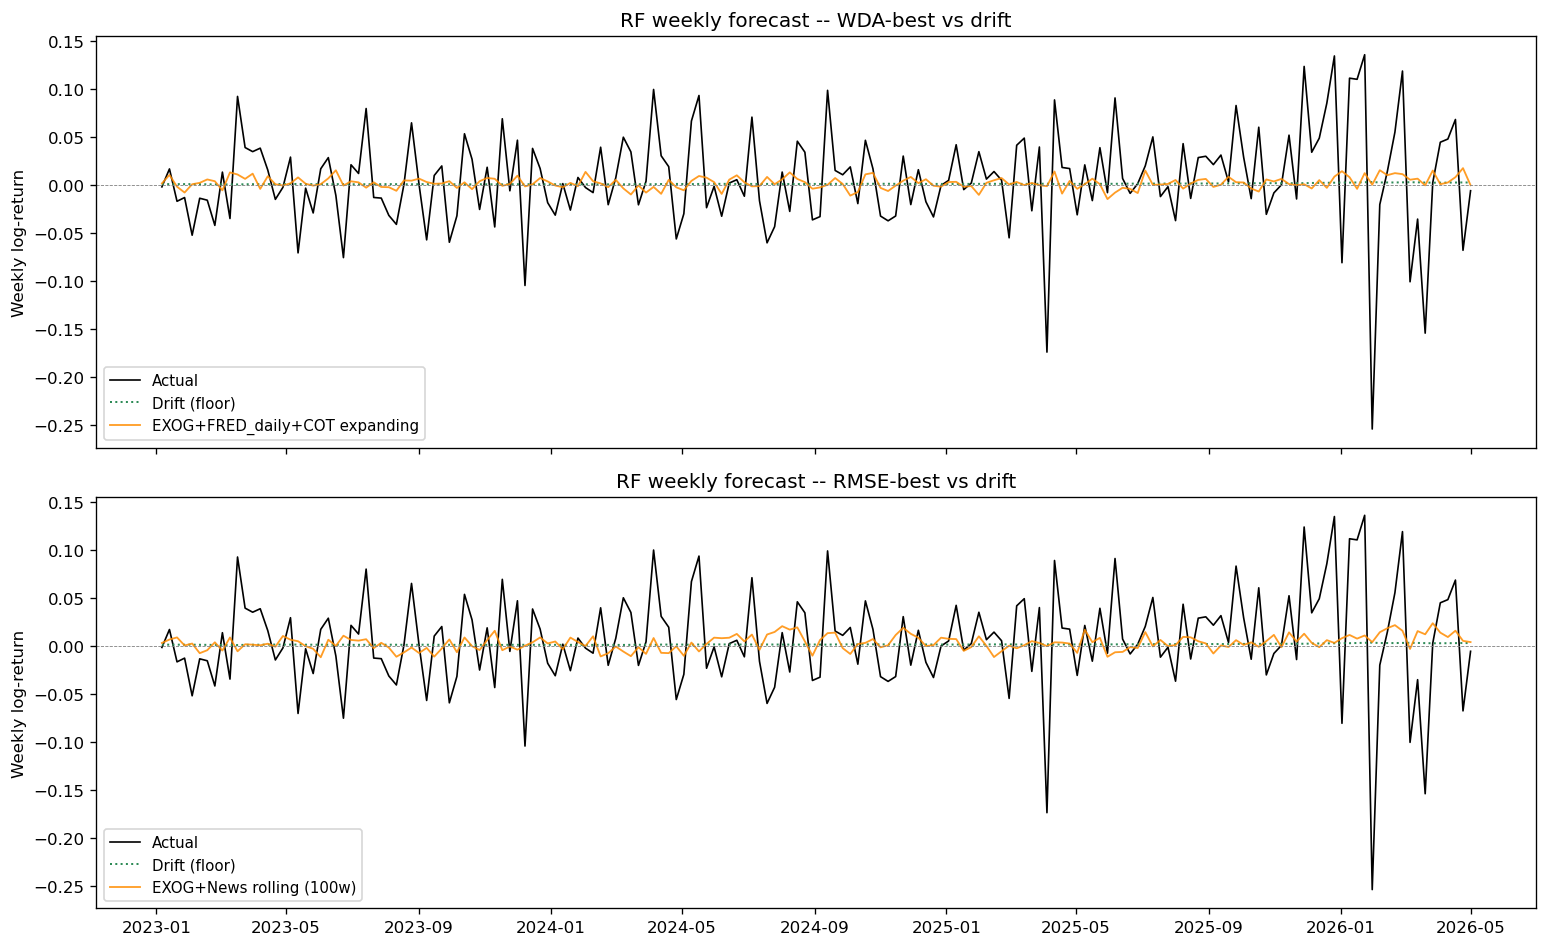

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
panels = [('WDA-best', best_name, best_pred), ('RMSE-best', best_name_rmse, best_pred_rmse)]
for ax, (tag, vname, vpred) in zip(axes, panels):
    ax.plot(test_index, y_test,     label='Actual',        lw=1,   color='black')
    ax.plot(test_index, drift_pred, label='Drift (floor)', lw=1.2, ls=':', color='seagreen')
    ax.plot(test_index, vpred,      label=vname,           lw=1.1, alpha=0.85, color='darkorange')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.set_title(f'RF weekly forecast -- {tag} vs drift')
    ax.set_ylabel('Weekly log-return')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Significance tests

The descriptive metrics in §5 rank the models; this section asks whether the differences are
**statistically real**. All tests are vs the **Drift** floor (prevailing mean = random walk).
Trees bundle own-history + public info, so this is a **semi-strong** test (weak form proper is
isolated in ARIMA). Effect size (OOS R²) is already in the §5 table; DM below supplies its
significance. Full definitions and Newey–West detail: `01_arima` §8 and [`notes.md`](notes.md).

| Test | Asks | Axis | Role |
|---|---|---|---|
| **DM — squared error** | Does *any* variant beat the random walk? | magnitude | **load-bearing** |
| **DM — absolute error** | …and does that survive heavy tails? | magnitude | robustness |
| **Pesaran–Timmermann** (§8b) | Do the *sign* calls beat chance? | direction | secondary |

**Sign convention:** `pred1` = Drift always. $d_t = \text{loss}(\text{Drift}) - \text{loss}(\text{model})$,
so **positive** DM = model beats Drift (evidence against efficiency); **negative** = Drift wins.

### DM — squared-error floor (load-bearing)

The headline efficiency test: does any variant produce significantly lower **squared** forecast
errors than the Drift? This is the proper significance test for the OOS R² in §5 — both are
MSFE-based, so DM is internally consistent with the effect size already shown.

In [9]:
# Semi-strong floor [PRIMARY] — squared-error loss vs Drift.
# DM is the significance test for the OOS R^2 in §5 (both MSFE-based).
print("Diebold-Mariano -- vs Drift floor   [squared error]")
print("Semi-strong test: can any variant beat the no-predictability drift?")
print("-" * 90)
for name, pred in all_candidates.items():
    diebold_mariano(y_test, drift_pred, pred, "Drift", name)

Diebold-Mariano -- vs Drift floor   [squared error]
Semi-strong test: can any variant beat the no-predictability drift?
------------------------------------------------------------------------------------------
Drift                                    vs EXOG expanding                            DM=-2.073  p=0.038  *     -> winner: Drift
Drift                                    vs EXOG rolling (100w)                       DM=-2.304  p=0.021  *     -> winner: Drift
Drift                                    vs Tech expanding                            DM=-1.562  p=0.118  (ns)  -> winner: tie
Drift                                    vs Tech rolling (100w)                       DM=-0.727  p=0.467  (ns)  -> winner: tie
Drift                                    vs EXOG+GS expanding                         DM=+0.168  p=0.866  (ns)  -> winner: tie
Drift                                    vs EXOG+GS rolling (100w)                    DM=-0.700  p=0.484  (ns)  -> winner: tie
Drift                  

### DM — absolute-error (robustness)

Same framework, loss $\lvert y-\hat y\rvert$ instead of $(y-\hat y)^2$. Weekly silver returns
are heavy-tailed — a few outlier weeks (squeeze, COVID, 2025 bull leg) dominate squared loss.
Absolute-error checks whether the result survives a less outlier-sensitive criterion. Squared
error stays the headline.

In [10]:
# Robustness -- floor test under ABSOLUTE-error loss.
print("Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]")
print("-" * 90)
for name, pred in all_candidates.items():
    diebold_mariano(y_test, drift_pred, pred, "Drift", name, loss='ae')

Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]
------------------------------------------------------------------------------------------
Drift                                    vs EXOG expanding                            DM=-0.848  p=0.397  (ns)  -> winner: tie
Drift                                    vs EXOG rolling (100w)                       DM=-1.548  p=0.122  (ns)  -> winner: tie
Drift                                    vs Tech expanding                            DM=-1.315  p=0.188  (ns)  -> winner: tie
Drift                                    vs Tech rolling (100w)                       DM=-0.431  p=0.667  (ns)  -> winner: tie
Drift                                    vs EXOG+GS expanding                         DM=+1.097  p=0.273  (ns)  -> winner: tie
Drift                                    vs EXOG+GS rolling (100w)                    DM=+0.024  p=0.981  (ns)  -> winner: tie
Drift                                    vs EXOG+NonLin expanding            

## 8b. Directional test — Pesaran–Timmermann (secondary lens)

DM is a *magnitude* test; DA/WDA are *directional*, so their significance needs **Pesaran–
Timmermann (1992)** — H0: predicted & actual signs independent (base-rate aware; *degenerate*
for a constant-sign forecast like the drift). **Secondary** to the DM-vs-Drift magnitude
verdict. Run across all variants to size the selection / multiple-testing picture.

In [11]:
from eval_utils import pesaran_timmermann

print("Pesaran-Timmermann directional test — full test window")
print("H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001")
print("-" * 90)
pesaran_timmermann(y_test, drift_pred, name="Drift (always-up)")   # degenerate ref
pt_results = {n: pesaran_timmermann(y_test, p, name=n) for n, p in all_candidates.items()}
_tested = [r for r in pt_results.values() if not np.isnan(r['p'])]
_sig    = {n: r for n, r in pt_results.items() if not np.isnan(r['p']) and r['p'] < 0.05}
print(f"\n{len(_sig)}/{len(_tested)} variants significant at p<0.05 "
      f"(~{0.05 * len(_tested):.1f} expected by chance): {list(_sig)}")

print(f"\nPer-period PT — {best_name}:")
_yt = pd.Series(y_test, index=test_index)
_bp = pd.Series(best_pred, index=test_index)
for _lbl, (_a, _b) in PERIODS.items():
    _yy = _yt.loc[_a:_b].values
    _pp = _bp.loc[_a:_b].values
    if len(_yy) >= 12:
        pesaran_timmermann(_yy, _pp, name=f"  {_lbl}  (n={len(_yy)})")

Pesaran-Timmermann directional test — full test window
H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001
------------------------------------------------------------------------------------------
Drift (always-up)                         DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
EXOG expanding                            DA=0.511  DA|indep=0.510  PT=+0.043  p=0.966  (ns)  -> winner: tie (chance)
EXOG rolling (100w)                       DA=0.494  DA|indep=0.511  PT=-0.442  p=0.658  (ns)  -> winner: tie (chance)
Tech expanding                            DA=0.471  DA|indep=0.503  PT=-0.837  p=0.403  (ns)  -> winner: tie (chance)
Tech rolling (100w)                       DA=0.546  DA|indep=0.481  PT=+1.840  p=0.066  (ns)  -> winner: tie (chance)
EXOG+GS expanding                         DA=0.529  DA|indep=0.526  PT=+0.069  p=0.945  (ns)  -> winner: tie (chance)
EXOG+GS rolling (100w)                    DA=0.534  DA|indep=0.

## 8c. Robustness — drop the 2025 bull run (full battery)

2025 carries the entire always-up line, so once the full-window tests are done, re-run **the whole
battery** — metrics + OOS R² + DM floor (se/ae) + PT — on **2023 + 2024 + 2026** only. Evaluation-only
(models unchanged, still trained walk-forward through 2025); pooled (per-year DM is underpowered). The
efficiency conclusion *strengthens* once the bull is removed.

In [12]:
from eval_utils import pesaran_timmermann
# Full battery on the non-bull window. Evaluation-only (forecasts unchanged); pooled for DM power.
mask_ex25 = np.asarray(test_index.year != 2025)
a_ex      = y_test[mask_ex25]
drift_ex  = drift_pred[mask_ex25]
au_ex     = np.sum(np.abs(a_ex) * (a_ex > 0)) / np.sum(np.abs(a_ex))
print(f'Ex-2025 sample: {int(mask_ex25.sum())} weeks  |  always-up WDA = {au_ex:.3f}')

print('\nMetrics (2025 excluded) -- RMSE / MAE / DA / WDA:')
evaluate('Drift (prevailing mean)', a_ex, drift_ex)
for name, pred in all_candidates.items():
    evaluate(name, a_ex, np.asarray(pred)[mask_ex25])

print('\nOOS R^2 vs Drift (2025 excluded) -- >0 beats the random walk:')
print('-' * 90)
for name, pred in all_candidates.items():
    _r2 = oos_r2(a_ex, np.asarray(pred)[mask_ex25], drift_ex) * 100
    print(f'  {name:40s} R2_OS = {_r2:+6.2f}%   -> winner: {name if _r2 > 0 else "Drift"}')

print('\nDM -- vs Drift floor, 2025 excluded [squared error]:')
print('-' * 90)
for name, pred in all_candidates.items():
    diebold_mariano(a_ex, drift_ex, np.asarray(pred)[mask_ex25], 'Drift', name)

print('\nDM -- vs Drift floor, 2025 excluded [absolute-error loss, robustness]:')
print('-' * 90)
for name, pred in all_candidates.items():
    diebold_mariano(a_ex, drift_ex, np.asarray(pred)[mask_ex25], 'Drift', name, loss='ae')

print('\nPesaran-Timmermann (2025 excluded) -- directional sign test:')
print('-' * 90)
for name, pred in all_candidates.items():
    pesaran_timmermann(a_ex, np.asarray(pred)[mask_ex25], name=name)

Ex-2025 sample: 122 weeks  |  always-up WDA = 0.520

Metrics (2025 excluded) -- RMSE / MAE / DA / WDA:
Drift (prevailing mean)                        RMSE=0.05275  MAE=0.03796  DA=0.500  WDA=0.520
EXOG expanding                                 RMSE=0.05449  MAE=0.03853  DA=0.516  WDA=0.504
EXOG rolling (100w)                            RMSE=0.05524  MAE=0.03953  DA=0.484  WDA=0.457
Tech expanding                                 RMSE=0.05432  MAE=0.03833  DA=0.500  WDA=0.496
Tech rolling (100w)                            RMSE=0.05358  MAE=0.03771  DA=0.557  WDA=0.522
EXOG+GS expanding                              RMSE=0.05243  MAE=0.03775  DA=0.516  WDA=0.520
EXOG+GS rolling (100w)                         RMSE=0.05309  MAE=0.03812  DA=0.516  WDA=0.504
EXOG+NonLin expanding                          RMSE=0.05348  MAE=0.03812  DA=0.516  WDA=0.505
EXOG+NonLin rolling (100w)                     RMSE=0.05556  MAE=0.03911  DA=0.492  WDA=0.475
EXOG+Tech expanding                            RMSE

## 9. 2026 zoom — actual vs best variants

Two panels (WDA-best | RMSE-best) on the 2026 YTD slice, drift overlaid. The RMSE-best hugs the
drift (minimising squared error ≈ reproducing the random walk); the WDA-best is the directional bettor.

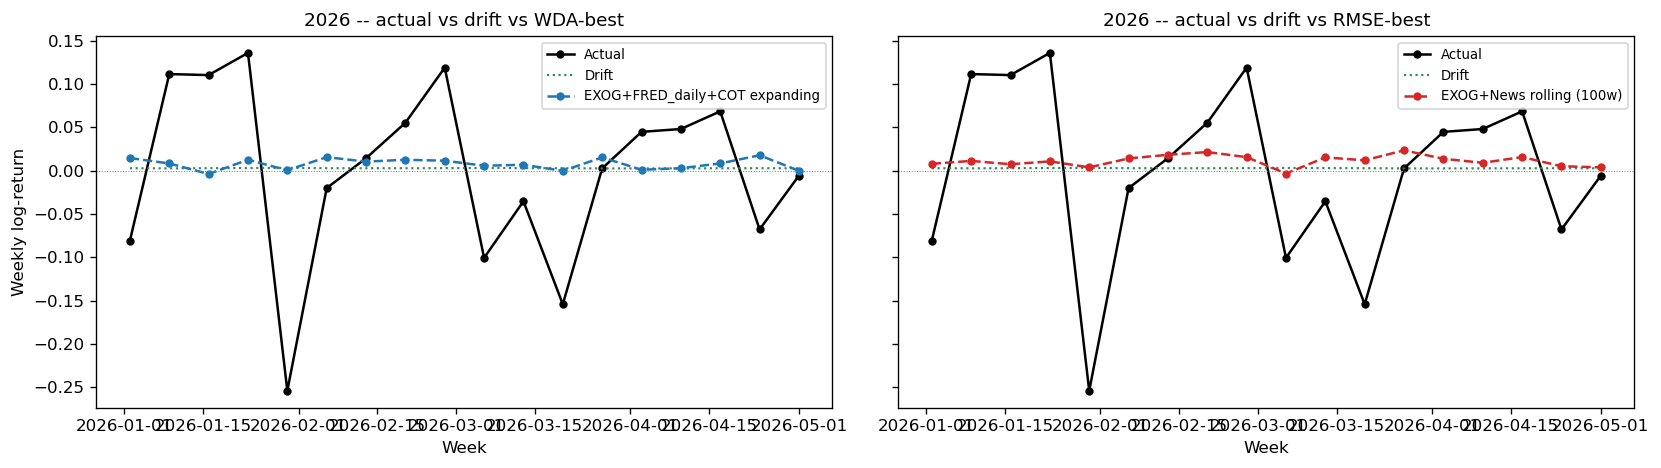

In [13]:
df26 = pd.DataFrame({'actual': y_test, 'drift': drift_pred,
                     'wda_best': best_pred, 'rmse_best': best_pred_rmse},
                    index=test_index).loc['2026':]

if df26.empty:
    print('No 2026 data in test set yet.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
    panels = [('wda_best', best_name, '#1f77b4', 'WDA-best'),
              ('rmse_best', best_name_rmse, '#d62728', 'RMSE-best')]
    for ax, (col, vname, color, tag) in zip(axes, panels):
        ax.plot(df26.index, df26['actual'], color='black',    lw=1.5, marker='o', ms=4, label='Actual')
        ax.plot(df26.index, df26['drift'],  color='seagreen', lw=1.3, ls=':',  label='Drift')
        ax.plot(df26.index, df26[col],      color=color,      lw=1.5, marker='o', ms=4, ls='--', label=vname)
        ax.axhline(0, color='grey', lw=0.6, ls=':')
        ax.set_title(f'2026 -- actual vs drift vs {tag}', fontsize=11)
        ax.set_xlabel('Week')
        ax.legend(fontsize=8)
    axes[0].set_ylabel('Weekly log-return')
    plt.tight_layout()
    plt.show()

## 10. Feature importance (EXOG+ALL model)

**Permutation importance (not MDI)** from a single RF fit on the **full EXOG+ALL feature set** (train+val) with that rung's tuned hyperparameters, then probed **out-of-sample on the test window**. The full set is deliberate: importance is a *ranking* exercise, so every candidate predictor has to be in the model to be ranked — restricting to the EXOG base would only rank the cross-asset lags and discard the whole "do macro / COT / sentiment matter?" question.

*Why permutation, not MDI.* MDI (the default `.feature_importances_`) is read off the trees *during training* from each feature's impurity reduction — it never sees held-out data and is upward-biased toward high-cardinality / continuous predictors (most of this set), so a feature can rank high just because the trees split on it often, not because those splits generalise. Permutation instead **freezes the fitted model** and, one feature at a time, **shuffles that column on the test rows and measures the RMSE increase** — a direct read of out-of-sample contribution. (Caveat: with correlated predictors a shuffled feature can be "covered" by its correlate, so both look weaker than they are — read groups, not single bars; SHAP would handle this but is overkill for a descriptive plot.)

Descriptive only; the load-bearing verdict is the Drift-floor DM battery in §8. 

**Reading the plot:** each bar is the *mean* RMSE increase across the 30 shuffle repeats — longer = the model leaned on that feature more; the whiskers are the spread across repeats, so wide whiskers mean an unstable estimate (trust that feature's rank less); the dashed line is zero, and bars that barely reach it — or fall to its left — added essentially nothing (shuffling them didn't hurt, or even helped by chance). Expect most bars near zero here: with no variant beating drift out-of-sample, that *is* the signature of a feature set carrying no exploitable signal.

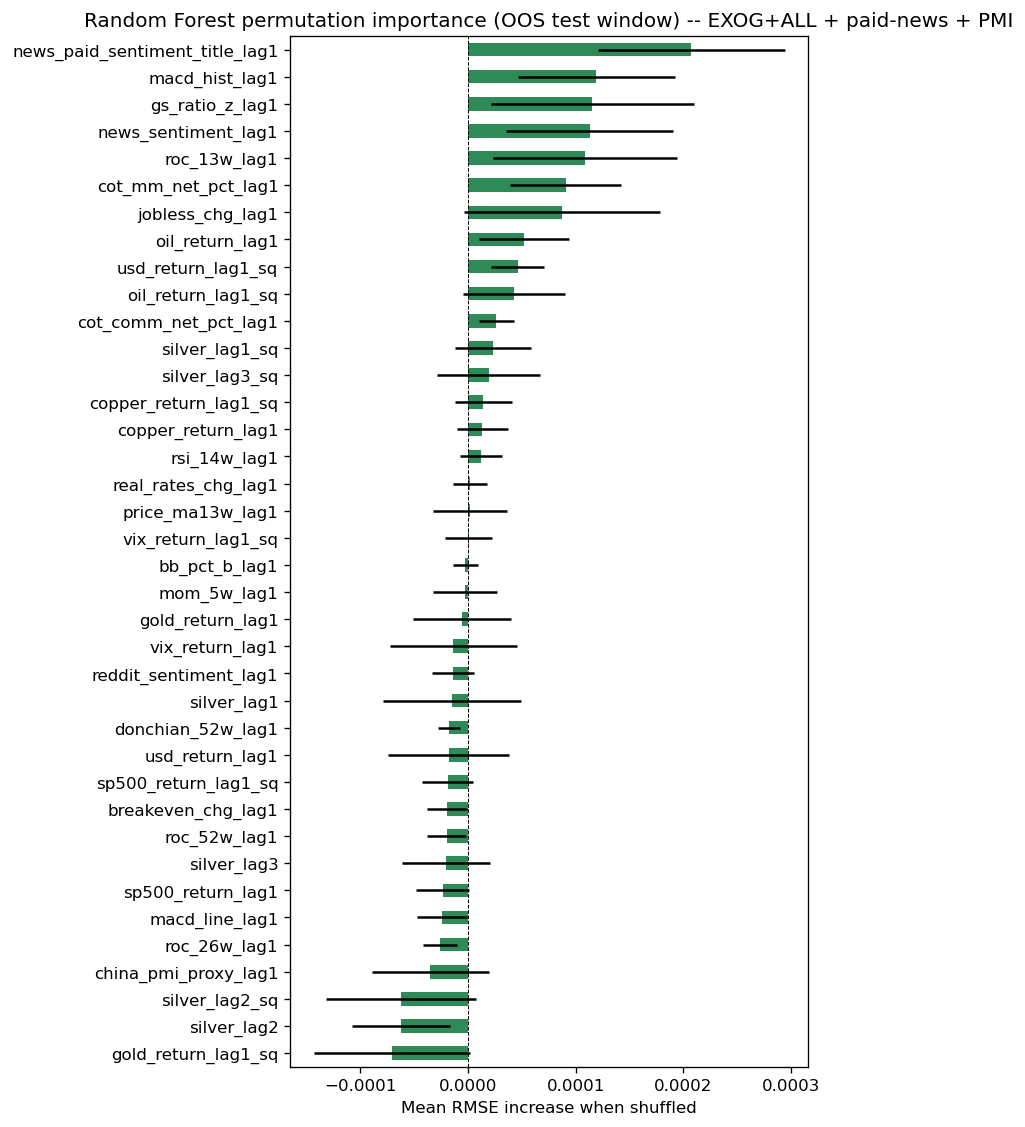

news_paid_sentiment_title_lag1    2.072942e-04
macd_hist_lag1                    1.190666e-04
gs_ratio_z_lag1                   1.152716e-04
news_sentiment_lag1               1.130483e-04
roc_13w_lag1                      1.086083e-04
cot_mm_net_pct_lag1               9.069061e-05
jobless_chg_lag1                  8.735321e-05
oil_return_lag1                   5.220593e-05
usd_return_lag1_sq                4.612496e-05
oil_return_lag1_sq                4.263812e-05
cot_comm_net_pct_lag1             2.631545e-05
silver_lag1_sq                    2.313294e-05
silver_lag3_sq                    1.906094e-05
copper_return_lag1_sq             1.416148e-05
copper_return_lag1                1.341935e-05
rsi_14w_lag1                      1.172142e-05
real_rates_chg_lag1               1.873358e-06
price_ma13w_lag1                  1.849588e-06
vix_return_lag1_sq                5.507430e-07
bb_pct_b_lag1                    -2.728270e-06
dtype: float64


In [14]:
# Fit one RF on the full EXOG+ALL feature set (train+val) with its tuned params, then PROBE it
# out-of-sample: permutation importance on the held-out test window. The fitted model is frozen;
# each feature column is shuffled across the test rows and the resulting RMSE increase is its score.
from sklearn.inspection import permutation_importance

imp_feats = features_all[ALL_BASE].copy()
# Importance superset: EXOG+ALL + paid-news title + PMI, so the new features rank alongside GDELT
# news / cross-assets (descriptive; reuses the EXOG+ALL tuned params, not a separate tuned rung).
for col_name, series in {**ALL_EXTRA, **NEWSPAID_COLS, **PMI_COLS}.items():
    imp_feats[col_name] = series.reindex(imp_feats.index).ffill()
imp_cols = imp_feats.columns.tolist()

X_tr = imp_feats.iloc[:n_train][imp_cols].values
y_tr = all_w[TARGET].iloc[:n_train].values
tr_mask = ~np.isnan(X_tr).any(axis=1)
X_te = imp_feats.iloc[n_train:][imp_cols].values
y_te = all_w[TARGET].iloc[n_train:].values
te_mask = ~np.isnan(X_te).any(axis=1) & ~np.isnan(y_te)

imp_model = RandomForestRegressor(random_state=42, n_jobs=-1, **variant_params['EXOG+ALL'])
imp_model.fit(X_tr[tr_mask], y_tr[tr_mask])

# Permutation importance on the held-out test window (frozen model; RMSE increase per shuffled feature).
perm = permutation_importance(imp_model, X_te[te_mask], y_te[te_mask],
                              scoring='neg_root_mean_squared_error', n_repeats=30,
                              random_state=42, n_jobs=-1)
importances = pd.Series(perm.importances_mean, index=imp_cols).sort_values()
imp_std = pd.Series(perm.importances_std, index=imp_cols).reindex(importances.index)

fig, ax = plt.subplots(figsize=(7, max(4, 0.25 * len(imp_cols))))
importances.plot.barh(ax=ax, color='seagreen', xerr=imp_std)
ax.axvline(0, color='black', lw=0.6, ls='--')
ax.set_title('Random Forest permutation importance (OOS test window) -- EXOG+ALL + paid-news + PMI')
ax.set_xlabel('Mean RMSE increase when shuffled')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False).head(20))